1.Importing the Dependencies

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib # To save the model as .sav file

2.Data Cleaning

In [50]:
# Loading the dataset
data = pd.read_csv('creditcard.csv')

# Checking for missing values
print(data.isnull().sum())

# Dropping missing values if any (usually not required for this dataset)
data = data.dropna()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Scaling Time and Amount columns
data['Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data['Time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


3.Data Visualization

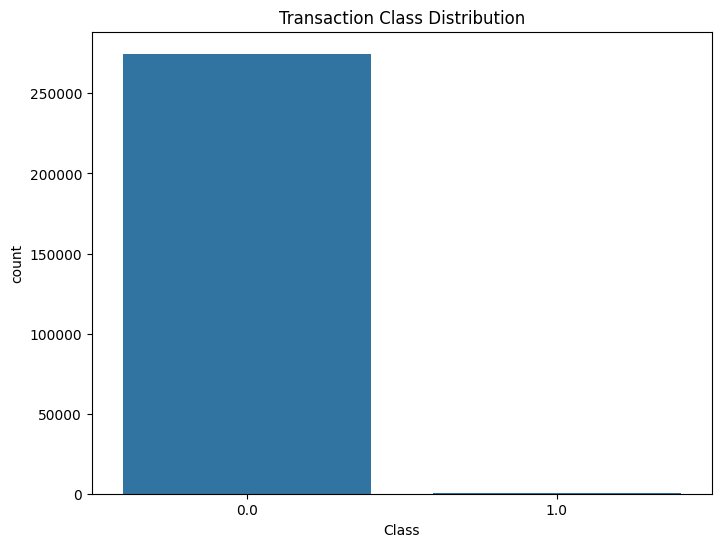

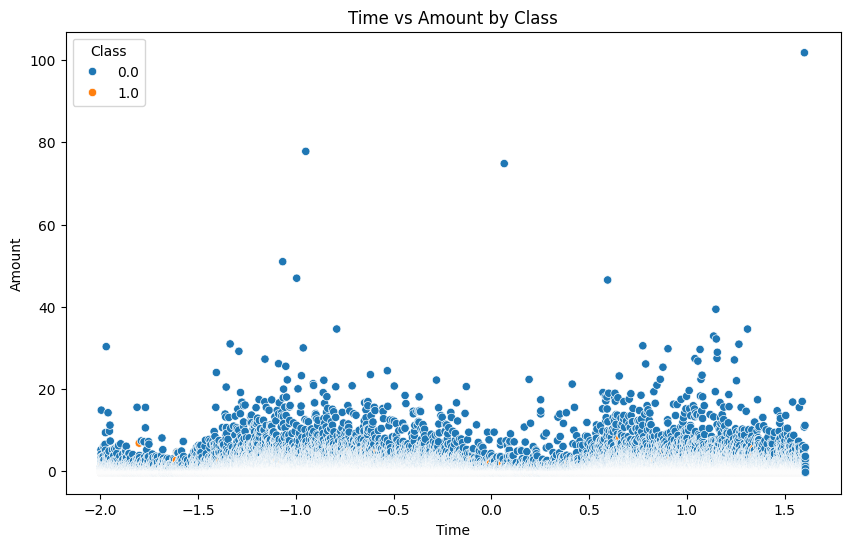

In [51]:
# Plotting the distribution of Class (0: Normal, 1: Fraud)
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=data)
plt.title('Transaction Class Distribution')
plt.show()

# Time vs Amount distribution
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=data)
plt.title('Time vs Amount by Class')
plt.show()

4.Exploratory Data Analysis (EDA)

In [52]:
# Statistical summary
print(data.describe())

# Checking the number of fraud and legitimate transactions
legit = data[data.Class == 0]
fraud = data[data.Class == 1]

print(f"Legit transactions: {legit.shape}")
print(f"Fraud transactions: {fraud.shape}")

# Comparing values for both transactions
print(data.groupby('Class').mean())

               Time             V1             V2             V3  \
count  2.752380e+05  275238.000000  275238.000000  275238.000000   
mean   9.252302e-17      -0.003958      -0.010540       0.026984   
std    1.000002e+00       1.957614       1.653397       1.512946   
min   -1.996576e+00     -56.407510     -72.715728     -48.325589   
25%   -8.458815e-01      -0.920601      -0.605176      -0.849379   
50%   -2.159125e-01       0.019750       0.060575       0.212365   
75%    9.522425e-01       1.302827       0.792921       1.048210   
max    1.606730e+00       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  275238.000000  275238.000000  275238.000000  275238.000000   
mean        0.005426      -0.010856       0.004769      -0.004534   
std         1.416443       1.381968       1.331548       1.238366   
min        -5.683171    -113.743307     -26.160506     -43.557242   
25%        -0.847148      -0.702759      -

5.Data Modeling

In [53]:
# Taking a random sample from legit transactions to match fraud count (492)
legit_sample = legit.sample(n=492)

# Concatenating two dataframes
new_dataset = pd.concat([legit_sample, fraud], axis=0)

print(new_dataset['Class'].value_counts())

Class
0.0    492
1.0    484
Name: count, dtype: int64


6.Splitting the Data into Features and Targets

In [54]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

7.Splitting the Data into Test and Training Data

In [55]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

8.Model Training

In [56]:
from sklearn.ensemble import RandomForestClassifier

# Initializing Random Forest with 100 trees
model = RandomForestClassifier(n_estimators=100, random_state=2)

# Training the model
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=2)

9.Model Evaluation

In [57]:
# Accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print(f'Accuracy on Test data: {test_data_accuracy}')

# Classification Report (Check Recall and Precision)
print(classification_report(Y_test, X_test_prediction))

Accuracy on Test data: 0.9336734693877551
              precision    recall  f1-score   support

         0.0       0.90      0.98      0.94        99
         1.0       0.98      0.89      0.93        97

    accuracy                           0.93       196
   macro avg       0.94      0.93      0.93       196
weighted avg       0.94      0.93      0.93       196



10.Communication and Visualization (Confusion Matrix)

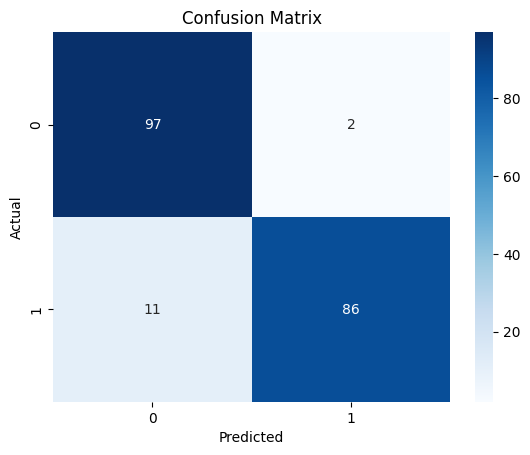

In [58]:
conf_matrix = confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

11.Model Saving

In [59]:
# Saving the model using joblib
filename = 'credit_card_model.sav'
joblib.dump(model, filename)
print(f"Model saved successfully as {filename}")

Model saved successfully as credit_card_model.sav
